# 04 — ML: Clustering (Aprendizado Não-Supervisionado)
**Projeto: Data Science dos Santos Católicos**

**Pergunta:** *Existem grupos naturais de santos que emergem dos dados sem usar os rótulos (categoria)?*

**Técnicas usadas:**
- **K-Means** — agrupa santos por similaridade numérica
- **PCA** — reduz dimensões para visualizar em 2D
- **t-SNE** — outra redução 2D, preserva estrutura local
- **Dendrograma** — mostra hierarquia entre grupos

A ideia é verificar se o algoritmo "re-descobre" as categorias históricas (Mártir, Confessor, Doutor) sem receber essa informação.

## Setup

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

PROJECT_ROOT = Path(os.getcwd()).parent
DATA_PROC    = PROJECT_ROOT / 'data' / 'processed'
FIGS         = PROJECT_ROOT / 'outputs' / 'figures'
MODELS       = PROJECT_ROOT / 'outputs' / 'models'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 12,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid')

CORES_CAT = {'Martyr':'#C0392B','Confessor':'#2980B9','Doctor':'#F39C12','Virgin':'#8E44AD','Other':'#95A5A6'}

df = pd.read_csv(DATA_PROC / 'saints_clean.csv')
print(f'Dataset: {df.shape}')

Dataset: (77, 19)


## 1. Preparar Features para Clustering

In [11]:
# Features numéricas e categóricas para o clustering
features_num = ['death_year', 'century_of_death', 'years_to_canonization', 'num_patron_topics']
features_num = [f for f in features_num if f in df.columns]

# Codificar continente como número
df_ml = df.copy()
le = LabelEncoder()
if 'continent' in df_ml.columns:
    df_ml['continent_enc'] = le.fit_transform(df_ml['continent'].fillna('Unknown'))
    features_num.append('continent_enc')

# Flags booleanas
for flag in ['is_martyr', 'is_doctor', 'is_virgin']:
    if flag in df_ml.columns:
        df_ml[flag] = df_ml[flag].astype(int)
        features_num.append(flag)

# Remover colunas que têm todos os valores vazios
features_num = [f for f in features_num if df_ml[f].notna().sum() > 0]

# Remover linhas sem ano de morte
df_cluster = df_ml[features_num + ['name', 'category']].dropna(subset=['death_year']).copy()

X = df_cluster[features_num].values

# Imputar NaN com a mediana de cada coluna
imputer = SimpleImputer(strategy='median')
X = imputer.fit_transform(X)
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'Matriz de features: {X_scaled.shape}')
print(f'Features usadas: {features_num}')
print(f'NaN restantes: {np.isnan(X_scaled).sum()}')  # deve ser 0

Matriz de features: (77, 8)
Features usadas: ['death_year', 'century_of_death', 'years_to_canonization', 'num_patron_topics', 'continent_enc', 'is_martyr', 'is_doctor', 'is_virgin']
NaN restantes: 0


## 2. K-Means — Encontrar o Número Ideal de Clusters

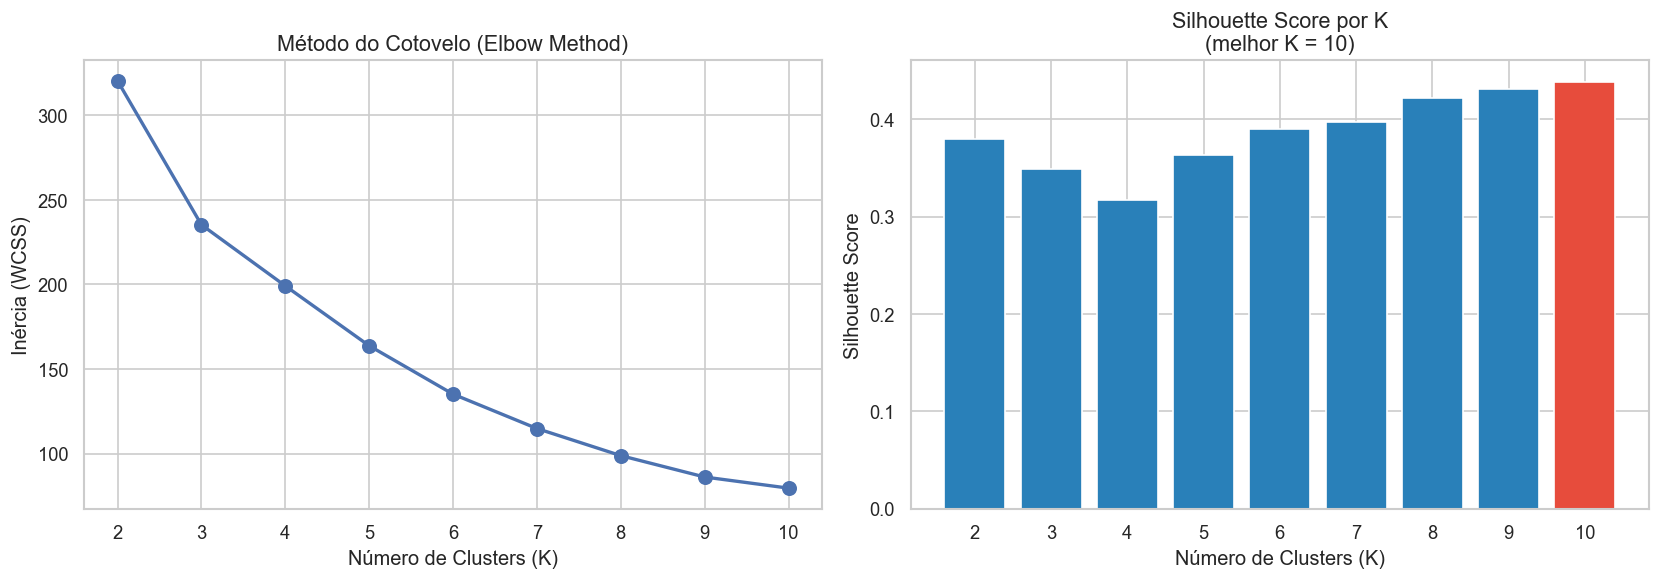

K ideal pelo Silhouette: 10


In [12]:
inercias     = []
silhouettes  = []
k_range      = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(list(k_range), inercias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia (WCSS)')
axes[0].set_title('Método do Cotovelo (Elbow Method)', fontsize=13)
axes[0].set_xticks(list(k_range))

# Silhouette scores
melhor_k = list(k_range)[np.argmax(silhouettes)]
cores_sil = ['#E74C3C' if k == melhor_k else '#2980B9' for k in k_range]
axes[1].bar(list(k_range), silhouettes, color=cores_sil)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title(f'Silhouette Score por K\n(melhor K = {melhor_k})', fontsize=13)
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.savefig(FIGS / '04_elbow_silhouette.png', bbox_inches='tight')
plt.show()
print(f'K ideal pelo Silhouette: {melhor_k}')

In [13]:
# Treinar K-Means final
K_FINAL = melhor_k  # ou troque manualmente (ex: 4)

km_final = KMeans(n_clusters=K_FINAL, random_state=42, n_init=20)
df_cluster = df_cluster.copy()
df_cluster['cluster'] = km_final.fit_predict(X_scaled)

print(f'Clusters formados com K={K_FINAL}:')
print(df_cluster['cluster'].value_counts().sort_index())

Clusters formados com K=10:
cluster
0     9
1     7
2    10
3     9
4    14
5     3
6    10
7     6
8     5
9     4
Name: count, dtype: int64


## 3. PCA — Visualizar Clusters em 2D

In [14]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explicada = pca.explained_variance_ratio_
print(f'Variância explicada: PC1={var_explicada[0]:.1%}, PC2={var_explicada[1]:.1%}')
print(f'Total: {sum(var_explicada):.1%}')

df_cluster['pca1'] = X_pca[:, 0]
df_cluster['pca2'] = X_pca[:, 1]

Variância explicada: PC1=53.0%, PC2=18.6%
Total: 71.5%


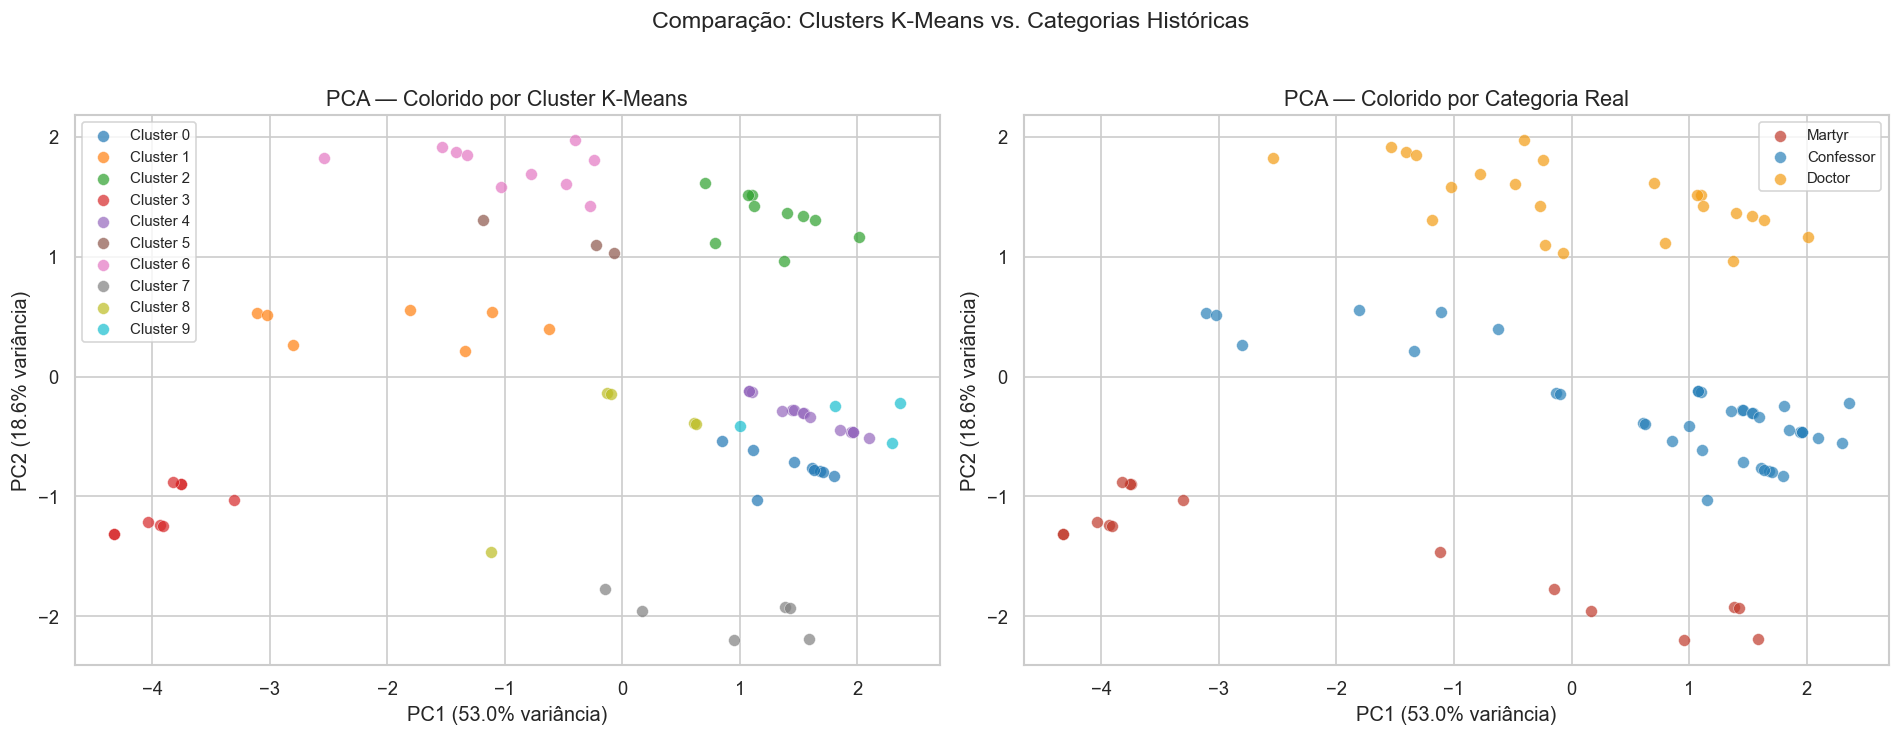

In [15]:
# Gerar cores suficientes para qualquer K
import matplotlib.cm as cm
cores_cluster = [cm.tab10(i) for i in range(K_FINAL)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# PCA colorido por CLUSTER
for cl in range(K_FINAL):
    mask = df_cluster['cluster'] == cl
    axes[0].scatter(df_cluster.loc[mask,'pca1'], df_cluster.loc[mask,'pca2'],
                    color=cores_cluster[cl], label=f'Cluster {cl}', alpha=0.7, s=50, edgecolors='white', linewidths=0.3)
axes[0].set_xlabel(f'PC1 ({var_explicada[0]:.1%} variância)')
axes[0].set_ylabel(f'PC2 ({var_explicada[1]:.1%} variância)')
axes[0].set_title('PCA — Colorido por Cluster K-Means', fontsize=13)
axes[0].legend(fontsize=9)

# PCA colorido por CATEGORIA REAL
for cat, cor in CORES_CAT.items():
    mask = df_cluster['category'] == cat
    if mask.sum() > 0:
        axes[1].scatter(df_cluster.loc[mask,'pca1'], df_cluster.loc[mask,'pca2'],
                        c=cor, label=cat, alpha=0.7, s=50, edgecolors='white', linewidths=0.3)
axes[1].set_xlabel(f'PC1 ({var_explicada[0]:.1%} variância)')
axes[1].set_ylabel(f'PC2 ({var_explicada[1]:.1%} variância)')
axes[1].set_title('PCA — Colorido por Categoria Real', fontsize=13)
axes[1].legend(fontsize=9)

plt.suptitle('Comparação: Clusters K-Means vs. Categorias Históricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / '04_pca_clusters.png', bbox_inches='tight')
plt.show()

## 4. t-SNE — Visualização com Estrutura Local Preservada

In [16]:
# t-SNE é mais lento — use perplexity menor para datasets menores
perp = min(30, len(X_scaled) // 5)
tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_iter=1000, verbose=0)
X_tsne = tsne.fit_transform(X_scaled)

df_cluster['tsne1'] = X_tsne[:, 0]
df_cluster['tsne2'] = X_tsne[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# t-SNE por cluster
for cl in range(K_FINAL):
    mask = df_cluster['cluster'] == cl
    axes[0].scatter(df_cluster.loc[mask,'tsne1'], df_cluster.loc[mask,'tsne2'],
                    color=cores_cluster[cl], label=f'Cluster {cl}', alpha=0.75, s=60, edgecolors='white', linewidths=0.3)
axes[0].set_title('t-SNE — Colorido por Cluster', fontsize=13)
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].legend(fontsize=9)

# t-SNE por categoria
for cat, cor in CORES_CAT.items():
    mask = df_cluster['category'] == cat
    if mask.sum() > 0:
        axes[1].scatter(df_cluster.loc[mask,'tsne1'], df_cluster.loc[mask,'tsne2'],
                        c=cor, label=cat, alpha=0.75, s=60, edgecolors='white', linewidths=0.3)
axes[1].set_title('t-SNE — Colorido por Categoria Real', fontsize=13)
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].legend(fontsize=9)

plt.suptitle('t-SNE: Estrutura Local dos Dados', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGS / '04_tsne.png', bbox_inches='tight')
plt.show()

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## 5. Perfil dos Clusters

In [ ]:
# Estatísticas por cluster
perfil = df_cluster.groupby('cluster')[features_num].mean().round(1)
print('Perfil médio de cada cluster:')
print(perfil.T.to_string())

# Categoria dominante em cada cluster
print('\nCategoria mais comum por cluster:')
for cl in range(K_FINAL):
    cat_dom = df_cluster[df_cluster['cluster'] == cl]['category'].value_counts().index[0]
    n = df_cluster[df_cluster['cluster'] == cl]['category'].value_counts().iloc[0]
    total = (df_cluster['cluster'] == cl).sum()
    print(f'  Cluster {cl}: {cat_dom} ({n}/{total} = {n/total:.0%})')

In [ ]:
# Radar chart de perfil dos clusters
features_radar = ['death_year', 'century_of_death', 'years_to_canonization', 'num_patron_topics']
features_radar = [f for f in features_radar if f in features_num]

# Normalizar 0–1 para o radar
perfil_radar = df_cluster.groupby('cluster')[features_radar].mean()
perfil_norm  = (perfil_radar - perfil_radar.min()) / (perfil_radar.max() - perfil_radar.min() + 1e-9)

N = len(features_radar)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # fechar o polígono

labels_radar = {
    'death_year': 'Ano\nMorte', 'century_of_death': 'Século',
    'years_to_canonization': 'Anos p/\nCanon.', 'num_patron_topics': 'Patronatos'
}

fig, axes = plt.subplots(1, K_FINAL, figsize=(4 * K_FINAL, 4),
                          subplot_kw={'projection': 'polar'})
if K_FINAL == 1:
    axes = [axes]

for cl, ax in enumerate(axes):
    valores = perfil_norm.iloc[cl].tolist() + perfil_norm.iloc[cl].tolist()[:1]
    ax.plot(angles, valores, color=cores_cluster[cl], linewidth=2)
    ax.fill(angles, valores, color=cores_cluster[cl], alpha=0.25)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([labels_radar.get(f, f) for f in features_radar], fontsize=9)
    ax.set_yticklabels([])
    n_cl = (df_cluster['cluster'] == cl).sum()
    ax.set_title(f'Cluster {cl}\n(n={n_cl})', fontsize=11, pad=15)

plt.suptitle('Perfil Radar dos Clusters', fontsize=14, y=1.05)
plt.tight_layout()
plt.savefig(FIGS / '04_radar_clusters.png', bbox_inches='tight')
plt.show()

## 6. Dendrograma (Clustering Hierárquico)

In [ ]:
# Usar amostra para dendrograma não ficar ilegível
n_amostra = min(50, len(X_scaled))
idx_amostra = np.random.default_rng(42).choice(len(X_scaled), n_amostra, replace=False)
X_dend  = X_scaled[idx_amostra]
nomes_dend = df_cluster['name'].iloc[idx_amostra].values

Z = linkage(X_dend, method='ward')

fig, ax = plt.subplots(figsize=(16, 7))
dendrogram(
    Z, labels=nomes_dend, ax=ax,
    leaf_rotation=75, leaf_font_size=8,
    color_threshold=Z[-K_FINAL, 2]  # destaca os K clusters
)
ax.set_title(f'Dendrograma — Clustering Hierárquico (Ward, amostra de {n_amostra} santos)', fontsize=14)
ax.set_xlabel('Santos')
ax.set_ylabel('Distância')
ax.axhline(Z[-K_FINAL, 2], color='red', linestyle='--', lw=1.5, label=f'Corte para K={K_FINAL}')
ax.legend()

plt.tight_layout()
plt.savefig(FIGS / '04_dendrograma.png', bbox_inches='tight')
plt.show()

## 7. Salvar Resultados

In [ ]:
import pickle

# Salvar modelo K-Means
with open(MODELS / 'kmeans_santos.pkl', 'wb') as f:
    pickle.dump(km_final, f)

# Salvar scaler
with open(MODELS / 'scaler_clustering.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Salvar dataset com clusters
df_cluster.to_csv(DATA_PROC / 'saints_with_clusters.csv', index=False)

print(f'Modelos salvos em: {MODELS}')
print(f'Dataset com clusters: saints_with_clusters.csv')

## Próximo Passo

Abra o **Notebook 05 — ML: Classificação** para treinar um Random Forest e identificar quais features melhor separam mártires de confessores.